# **Project 46: Walmart Sales Forcasting**

***NumPy*** : *A fundamental library for numerical computations in Python, providing support for arrays and mathematical functions.*

***Pandas*** : *A powerful data manipulation and analysis library in Python, offering data structures like DataFrames for handling structured data.*

***Warnings*** : *A module in Python used to issue warnings and alerts to developers about potential issues in their code.*

***Matplotlib*** : *A comprehensive library for creating static, animated, and interactive visualizations in Python.*

***Seaborn*** : *A statistical data visualization library in Python built on top of Matplotlib, offering an easy way to create attractive and informative statistical graphics.*

# **Data Loading**

**We import these libraries for Data Loading, Data Cleaning, Data Visualization and EDA (Explorotory Data Analysis).**

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

**The warnings.simplefilter("ignore") command suppresses all warnings in a Python script.**

In [50]:
warnings.simplefilter("ignore")

**S3FS is a Python package that allows you to interact with Amazon S3 storage using the standard filesystem interface. Installing it enables seamless access to S3 buckets for reading and writing files.**

In [ ]:
!pip install s3fs

**This code reads the CSV file from the specified S3 bucket URL into a Pandas DataFrame, using anonymous access for the S3 bucket. The sales_data.head(5) command will display the first five rows of the dataset after loading.**

In [ ]:
s3_url = "s3://walmartsalesforcasting/sales_data.csv"
sales_data = pd.read_csv(s3_url, storage_options={"anon" : True})
sales_data.head(5)

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


**This code loads a CSV file from an S3 bucket into a Pandas DataFrame, using anonymous access for the S3 bucket. The sales_data.head(5) command then displays the first five rows of the loaded dataset.**

In [ ]:
s3_url = "s3://walmartsalesforcasting/features.csv"
features_data = pd.read_csv(s3_url, storage_options={"anon" : True})
features_data.head(5)

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


**This code loads the stores.csv file from the specified S3 bucket into a Pandas DataFrame, using anonymous access for the S3 bucket. The stores_data.head(5) command will display the first five rows of the dataset after loading.**

In [ ]:
s3_url = "s3://walmartsalesforcasting/stores.csv"
stores_data = pd.read_csv(s3_url, storage_options={"anon" : True})
stores_data.head(5)

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


**The sales_data.shape command returns a tuple representing the dimensions of the sales_data DataFrame, indicating the number of rows and columns it contains.**

In [54]:
sales_data.shape

(421570, 5)

# **Data Cleaning**

**The code filters the sales_data DataFrame to identify rows where the Weekly_Sales is less than or equal to zero, storing the result in sales_data_check. The sales_data_check.shape command then returns the dimensions of this filtered DataFrame, indicating how many such rows exist.**

In [55]:
sales_data_check = sales_data.loc[sales_data['Weekly_Sales'] <= 0]
sales_data_check.shape

(1358, 5)

**This code calculates the proportion of rows in the sales_data DataFrame where Weekly_Sales is less than or equal to zero. It divides the number of such rows (sales_data_check.shape[0]) by the total number of rows in sales_data (sales_data.shape[0]), providing the percentage of non-positive sales.**

In [56]:
sales_data_check.shape[0]/sales_data.shape[0]

0.003221291837654482

**This code converts the Store and Dept columns in the sales_data DataFrame to string data types. It also converts the IsHoliday column to integers by multiplying its values by 1, effectively changing boolean values (True/False) to 1/0.**

In [57]:
sales_data['Store'] = sales_data['Store'].astype(str)
sales_data['Dept'] = sales_data['Dept'].astype(str)
sales_data['IsHoliday'] = sales_data['IsHoliday'] * 1

**This code filters the sales_data DataFrame to keep only the rows where Weekly_Sales is greater than zero, effectively removing any non-positive sales entries. The sales_data.shape command then returns the dimensions of the filtered DataFrame, showing the number of rows and columns remaining after the filtering.**

In [58]:
sales_data = sales_data.loc[sales_data['Weekly_Sales'] > 0]
sales_data.shape

(420212, 5)

**The sales_data.dtypes command returns a Series that shows the data types of each column in the sales_data DataFrame. This helps in understanding the types of data stored in each column, such as integers, floats, or strings.**

In [59]:
sales_data.dtypes

,0
Store,object
Dept,object
Date,object
Weekly_Sales,float64
IsHoliday,int64


**This code converts the Store column in both the features_data and stores_data DataFrames to string data types. This ensures that the Store identifiers are treated as categorical string values, which can be useful for merging or comparison operations later on.**

In [60]:
features_data['Store'] = features_data['Store'].astype(str)
stores_data['Store'] = stores_data['Store'].astype(str)

**This code removes the IsHoliday column from the features_data DataFrame. The axis=1 argument specifies that a column (rather than a row) is being dropped, effectively reducing the DataFrame to only include the remaining columns.**

In [61]:
features_data = features_data.drop(['IsHoliday'], axis=1)

**This code fills missing values in the Unemployment and CPI columns of the features_data DataFrame with their respective column means. The inplace=True argument ensures that the changes are applied directly to the DataFrame without needing to create a new one.**

In [62]:
features_data['Unemployment'].fillna(features_data['Unemployment'].mean(), inplace=True)
features_data['CPI'].fillna(features_data['CPI'].mean(), inplace=True)

**The features_data.isnull().sum() command returns a Series showing the total number of missing (null) values in each column of the features_data DataFrame. This helps identify any remaining columns with missing data that may need to be addressed.**

In [63]:
features_data.isnull().sum()

,0
Store,0
Date,0
Temperature,0
Fuel_Price,0
MarkDown1,4158
MarkDown2,5269
MarkDown3,4577
MarkDown4,4726
MarkDown5,4140
CPI,0


**This code uses SimpleImputer from sklearn to fill missing values in the MarkDown1, MarkDown2, MarkDown3, MarkDown4, and MarkDown5 columns of the features_data DataFrame with their respective column means. After the imputation, features_data.isnull().sum() checks for any remaining missing values in the DataFrame, ensuring all nulls have been addressed.**

In [64]:
from sklearn.impute import SimpleImputer

Imputer = SimpleImputer(strategy="mean")

features_data["MarkDown1"] = Imputer.fit_transform(features_data[["MarkDown1"]])
features_data["MarkDown2"] = Imputer.fit_transform(features_data[["MarkDown2"]])
features_data["MarkDown3"] = Imputer.fit_transform(features_data[["MarkDown3"]])
features_data["MarkDown4"] = Imputer.fit_transform(features_data[["MarkDown4"]])
features_data["MarkDown5"] = Imputer.fit_transform(features_data[["MarkDown5"]])

features_data.isnull().sum()

,0
Store,0
Date,0
Temperature,0
Fuel_Price,0
MarkDown1,0
MarkDown2,0
MarkDown3,0
MarkDown4,0
MarkDown5,0
CPI,0


**This code finds the number of duplicate entries in the features_data DataFrame based on unique combinations of Store and Date. It subtracts the total row count from the count of unique combinations to determine how many duplicates are present.**

In [65]:
features_data.groupby(["Store", "Date"]).size().shape[0] - features_data.shape[0]

0

**This code calculates the number of duplicate entries in the sales_data DataFrame based on unique combinations of Store, Dept, and Date. It subtracts the total row count from the count of unique combinations to determine how many duplicates exist in those groupings.**

In [66]:
sales_data.groupby(["Store", "Dept", "Date"]).size().shape[0] - sales_data.shape[0]

0

**This code merges the sales_data and features_data DataFrames on the Store and Date columns using an inner join, resulting in a new DataFrame called sales_features_data. The sales_features_data.shape command then returns the dimensions of this merged DataFrame, indicating the number of rows and columns after the merge.**

In [67]:
sales_features_data = pd.merge(sales_data, features_data, on=['Store', 'Date'], how='inner')
sales_features_data.shape

(420212, 14)

**This code merges the sales_features_data and stores_data DataFrames on the Store column using an inner join, resulting in a new DataFrame called df. The df.shape command then returns the dimensions of this merged DataFrame, indicating the number of rows and columns after the merge.**

In [68]:
df = pd.merge(sales_features_data, stores_data, on='Store', how='inner')
df.shape

(420212, 16)

**The df.head(5) command displays the first five rows of the df DataFrame, providing a quick look at its structure and the data it contains after merging the sales_features_data and stores_data DataFrames.**

In [69]:
df.head(5)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,0,42.31,2.572,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,1,38.51,2.548,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,0,39.93,2.514,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,0,46.63,2.561,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,0,46.50,2.625,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.350143,8.106,A,151315


**This code converts the Date column in the df DataFrame to a datetime format and extracts the day, month, and year into separate columns named Day, Month, and Year, respectively. It then removes the original Date column, and df.head(5) displays the first five rows of the updated DataFrame, showing the new structure with the extracted date components.**

In [70]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["Day"] = df["Date"].dt.day
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

df.drop(columns = ["Date"], inplace=True)

df.head(5)

,Store,Dept,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Day,Month,Year
0,1,1,24924.50,0,42.31,2.572,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.096358,8.106,A,151315,5,2,2010
1,1,1,46039.49,1,38.51,2.548,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.242170,8.106,A,151315,12,2,2010
2,1,1,41595.55,0,39.93,2.514,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.289143,8.106,A,151315,19,2,2010
3,1,1,19403.54,0,46.63,2.561,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.319643,8.106,A,151315,26,2,2010
4,1,1,21827.90,0,46.50,2.625,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.350143,8.106,A,151315,5,3,2010


# **Data Visualization**

**This code creates a box plot to visualize the impact of holidays on weekly sales in the df DataFrame. It sets the x-axis to represent whether it is a holiday (IsHoliday) and the y-axis to show Weekly_Sales, using a color palette called "Set1." The plot is titled "Impact Of Holidays On Weekly Sales," with appropriate axis labels, and it displays the results using plt.show().**


**This graph illustrates the outliers in the "IsHoliday" column, specifically the values of 0 and 1, based on weekly sales.**

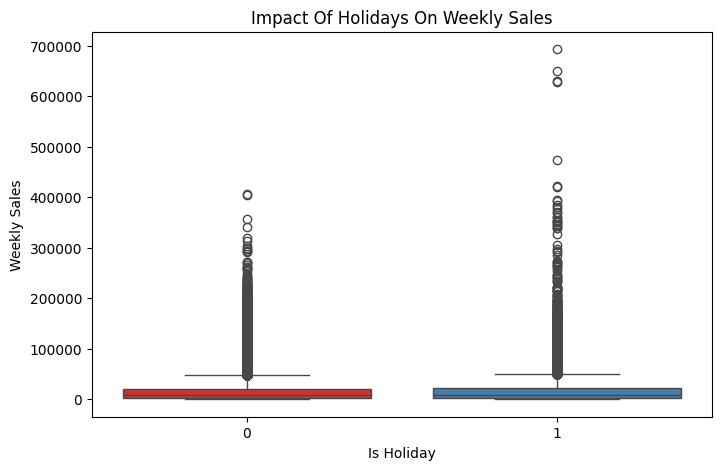

In [71]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='IsHoliday', y='Weekly_Sales', palette="Set1")
plt.title('Impact Of Holidays On Weekly Sales')
plt.xlabel('Is Holiday')
plt.ylabel('Weekly Sales')
plt.show()

**This code creates a scatter plot to examine the relationship between fuel prices and weekly sales in the df DataFrame. It uses Fuel_Price for the x-axis and Weekly_Sales for the y-axis, with points colored based on whether it is a holiday (IsHoliday). The plot is titled "Fuel Price vs Weekly Sales," and appropriate axis labels are provided, followed by displaying the plot with plt.show().**

**This graph displays fuel prices based on the "IsHoliday" status and compares them with weekly sales.**

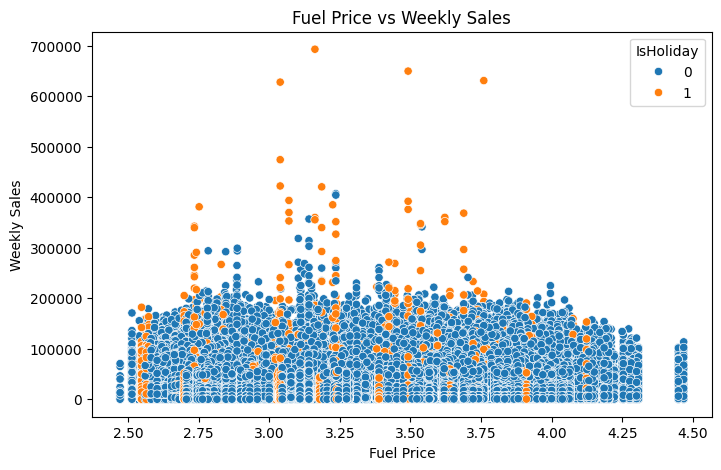

In [72]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Fuel_Price", y="Weekly_Sales", hue="IsHoliday")
plt.title("Fuel Price vs Weekly Sales")
plt.xlabel("Fuel Price")
plt.ylabel("Weekly Sales")
plt.show()

**This code generates a scatter plot to analyze the relationship between MarkDown1 and Weekly_Sales in the df DataFrame. It uses MarkDown1 for the x-axis and Weekly_Sales for the y-axis. The plot is titled "Markdown1 vs Weekly Sales," and appropriate axis labels are set, followed by displaying the plot using plt.show().**

**This graph shows the comparison between MarkDown1 and weekly sales.**

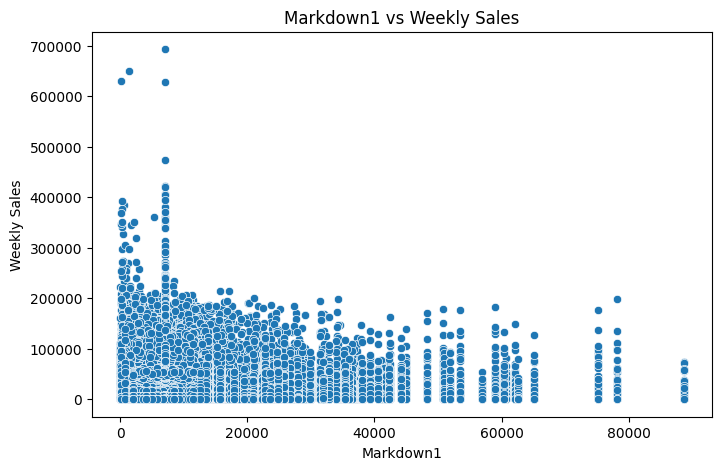

In [73]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="MarkDown1", y="Weekly_Sales")
plt.title("Markdown1 vs Weekly Sales")
plt.xlabel("Markdown1")
plt.ylabel("Weekly Sales")
plt.show()

**This code creates a scatter plot to explore the relationship between unemployment rates and weekly sales in the df DataFrame. The x-axis represents Unemployment, while the y-axis shows Weekly_Sales. The plot is titled "Unemployment vs Weekly Sales," and it includes appropriate labels for both axes, followed by displaying the plot with plt.show().**

**This graph depicts the relationship between unemployment and weekly sales.**

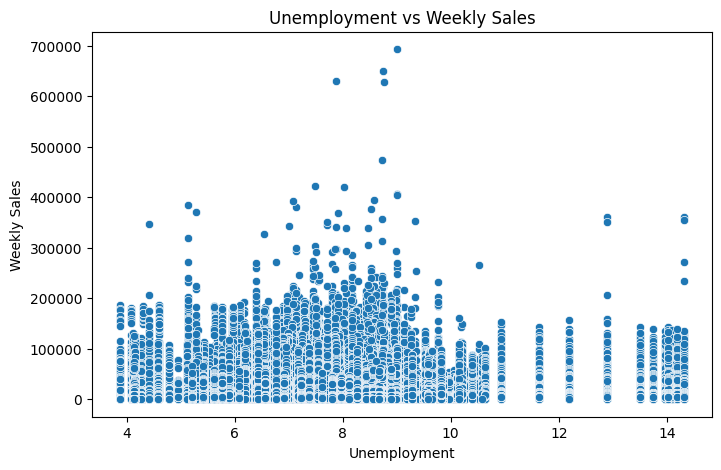

In [74]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Unemployment', y='Weekly_Sales')
plt.title('Unemployment vs Weekly Sales')
plt.xlabel('Unemployment')
plt.ylabel('Weekly Sales')
plt.show()

**This code generates a box plot to compare weekly sales across different stores in the df DataFrame. The x-axis represents the Store, while the y-axis shows Weekly_Sales. The plot is titled "Store-wise Weekly Sales Comparison," with labels for both axes, and the x-axis tick labels are rotated 90 degrees for better readability. The plot is displayed using plt.show().**

**This graph illustrates the relationship between each store and its weekly sales comparison.**

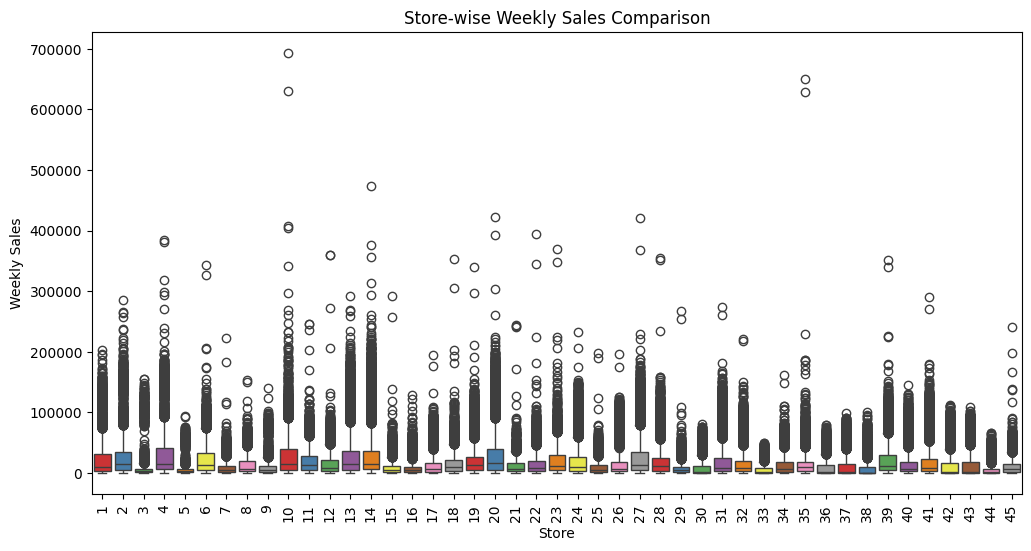

In [75]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Store', y='Weekly_Sales', palette="Set1")
plt.title('Store-wise Weekly Sales Comparison')
plt.xlabel('Store')
plt.ylabel('Weekly Sales')
plt.xticks(rotation=90)
plt.show()

**The command df.head(5) displays the first five rows of the df DataFrame, showing a snapshot of the data it contains, including columns such as Store, Weekly_Sales, Fuel_Price, MarkDown1, Unemployment, and any other relevant features added during the data processing steps.**

In [76]:
df.head(5)

,Store,Dept,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Day,Month,Year
0,1,1,24924.50,0,42.31,2.572,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.096358,8.106,A,151315,5,2,2010
1,1,1,46039.49,1,38.51,2.548,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.242170,8.106,A,151315,12,2,2010
2,1,1,41595.55,0,39.93,2.514,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.289143,8.106,A,151315,19,2,2010
3,1,1,19403.54,0,46.63,2.561,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.319643,8.106,A,151315,26,2,2010
4,1,1,21827.90,0,46.50,2.625,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.350143,8.106,A,151315,5,3,2010


**The command df["Type"].value_counts() returns the count of unique values in the Type column of the df DataFrame. This helps to identify the distribution of different types present in the dataset, providing insights into how many entries belong to each type category.**

In [77]:
df["Type"].value_counts()

,count
Type,
A,214961
B,162787
C,42464


**The code maps the categorical values in the Type column of the DataFrame df to numerical values, converting "A" to 0, "B" to 1, and "C" to 2. The df.head(5) command then displays the first five rows of the updated DataFrame, reflecting this transformation.**

In [78]:
map_Type = {"A" : 0, "B" : 1, "C" : 2}

df["Type"] = df["Type"].map(map_Type)

df.head(5)

,Store,Dept,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Day,Month,Year
0,1,1,24924.50,0,42.31,2.572,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.096358,8.106,0,151315,5,2,2010
1,1,1,46039.49,1,38.51,2.548,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.242170,8.106,0,151315,12,2,2010
2,1,1,41595.55,0,39.93,2.514,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.289143,8.106,0,151315,19,2,2010
3,1,1,19403.54,0,46.63,2.561,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.319643,8.106,0,151315,26,2,2010
4,1,1,21827.90,0,46.50,2.625,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.350143,8.106,0,151315,5,3,2010


**The code generates a heatmap to visualize the correlation matrix of the DataFrame df, using a "hot" colormap. The annot=True parameter displays the correlation coefficients on the heatmap, while linewidths=1.0 adds lines between the cells for clarity.**

<Axes: >

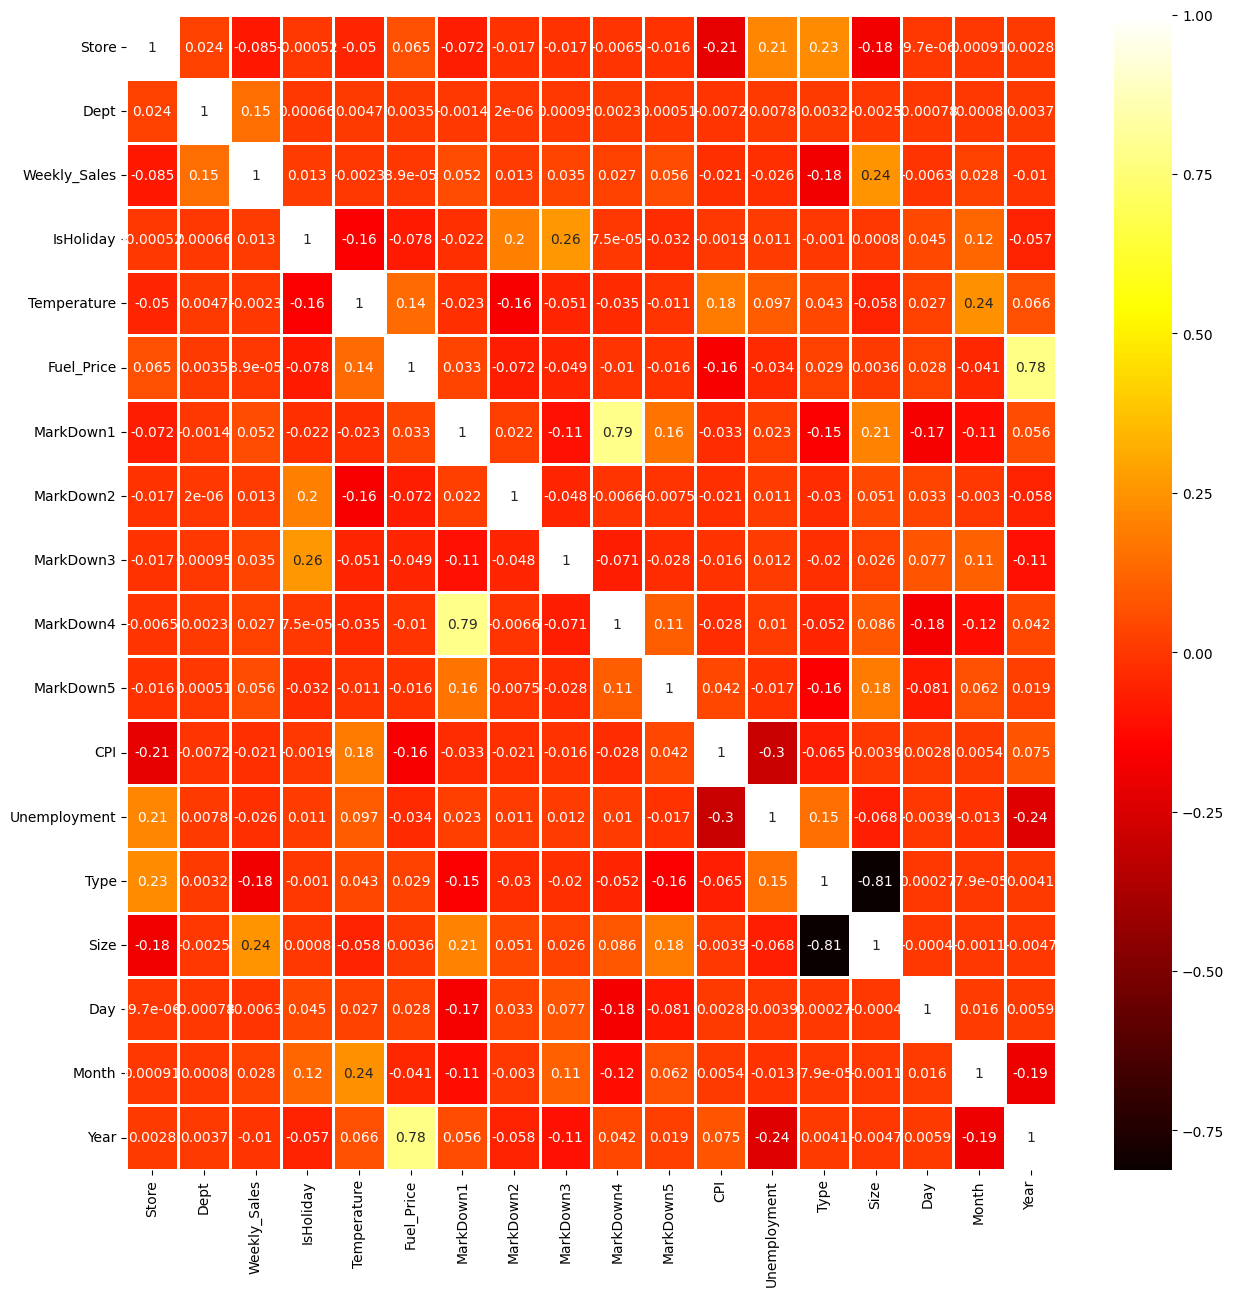

In [79]:
plt.figure(figsize=(15, 15))
sns.heatmap(df.corr(), cmap="hot", annot=True, linewidths=1.0)

**The command df.columns will display the names of all columns in the DataFrame df.**

In [80]:
df.columns

Index(['Store', 'Dept', 'Weekly_Sales', 'IsHoliday', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size', 'Day', 'Month',
       'Year'],
      dtype='object')

# **Model Building**

**In this code, you are defining your feature set X by selecting specific columns from the DataFrame df that you believe will help predict weekly sales. The target variable y is defined as the Weekly_Sales column. This setup prepares your data for training a machine learning model.**

In [81]:
X = df[['Store', 'Dept', 'IsHoliday', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size', 'Day', 'Month',
       'Year']]

y = df[["Weekly_Sales"]]

**The code applies Min-Max scaling to the feature set X and target variable y, transforming them to a range between 0 and 1. This helps ensure that all features contribute equally to model training. The set_output(transform="pandas") option keeps the output as a Pandas DataFrame. This scaling can enhance the performance of machine learning algorithms.**

In [82]:
from sklearn.preprocessing import MinMaxScaler

Scaler_X = MinMaxScaler().set_output(transform = "pandas")

X = Scaler_X.fit_transform(X)

Scaler_y = MinMaxScaler().set_output(transform = "pandas")

y = Scaler_y.fit_transform(y)

**This code imports the train_test_split function from sklearn.model_selection for splitting the dataset into training and testing sets. It also imports mean_squared_error from sklearn.metrics to evaluate the model's performance by calculating the mean squared error between predicted and actual values.**

In [83]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

**This code splits the dataset into training and testing sets, with 80% of the data used for training (X_train, y_train) and 20% for testing (X_test, y_test). The split ensures that the model can be trained effectively while still having a separate dataset to evaluate its performance.**

In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.80)

**This code returns the shapes of the training and testing datasets for both features (X) and target variable (y). It provides insights into the number of samples and features in each set, which is important for understanding the data distribution before training the model.**

In [85]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((336169, 17), (84043, 17), (336169, 1), (84043, 1))

**1: Model Initialization: A LinearRegression model is created with multiple jobs for parallel processing and fitting the intercept.**

**2: Model Training: The model is trained using the training datasets X_train and y_train.**

**3: Prediction: Predictions are made on the test set X_test using the trained model.**

**4: Evaluation: The Mean Squared Error (MSE) is calculated by comparing the predicted values (y_pred) to the actual values (y_test), and the result is printed.**

In [86]:
from sklearn.linear_model import LinearRegression

LR = LinearRegression(n_jobs = -1 , fit_intercept = True)

LR.fit(X_train, y_train)

y_pred = LR.predict(X_test)

MSE = mean_squared_error(y_pred, y_test)

print("Mean Squared Error For Linear Regression: ", MSE)

Mean Squared Error For Linear Regression:  0.0009721883756379288


**1: Model Initialization: A RandomForestRegressor is created with specified parameters: minimum samples for leaf nodes, minimum samples for splits, and maximum tree depth.**

**2: Model Training: The model is trained on the training datasets X_train and y_train.**

**3: Prediction: Predictions are made on the test set X_test using the trained model.**

**4: Evaluation: The Mean Squared Error (MSE) is calculated by comparing the predicted values (y_pred) to the actual values (y_test), and the result is printed.**

In [93]:
from sklearn.ensemble import RandomForestRegressor

RFR = RandomForestRegressor(min_samples_leaf=10, min_samples_split=20, max_depth = 50)

RFR.fit(X_train, y_train)

y_pred = LR.predict(X_test)

MSE = mean_squared_error(y_pred, y_test)

print("Mean Squared Error For Random Forest Regressor: ", MSE)

Mean Squared Error For Random Forest Regressor:  0.0009721883756379288


**1: Model Initialization: A DecisionTreeRegressor is created with specified parameters: complexity pruning (ccp_alpha) and maximum tree depth.**

**2: Model Training: The model is trained using the training datasets X_train and y_train.**

**3: Prediction: Predictions are generated for the test set X_test using the trained decision tree model.**

**4: Evaluation: The Mean Squared Error (MSE) is calculated by comparing the predicted values (y_pred) to the actual values (y_test), and the result is printed.**

In [40]:
from sklearn.tree import DecisionTreeRegressor

DTR = DecisionTreeRegressor(ccp_alpha= 1.0, max_depth = 50)

DTR.fit(X_train, y_train)

y_pred = DTR.predict(X_test)

MSE = mean_squared_error(y_pred, y_test)

print("Mean Squared Error For Decision Tree Regressor: ", MSE)

Mean Squared Error For Decision Tree Regressor:  0.001070737366248755


**1: Model Initialization: A Support Vector Regressor (SVR) is created with a regularization parameter C set to 1.0 and a maximum iteration limit of 500.**

**2: Model Training: The SVR model is trained using the training datasets X_train and y_train.**

**3: Prediction: Predictions are generated for the test set X_test using the trained SVR model.**

**4: Evaluation: The Mean Squared Error (MSE) is computed by comparing the predicted values (y_pred) to the actual values (y_test), and the result is printed.**

In [41]:
from sklearn.svm import SVR

svr = SVR(C=1.0 , max_iter=500)

svr.fit(X_train, y_train)

y_pred = svr.predict(X_test)

MSE = mean_squared_error(y_pred, y_test)

print("Mean Squared Error For Support Vector Regressor: ", MSE)

Mean Squared Error For Support Vector Regressor:  0.009479608542750062


**1: Model Initialization: A Ridge regression model is created with a tolerance level of 20 and an alpha (regularization strength) of 1.0.**

**2: Model Training: The Ridge model is trained using the training datasets X_train and y_train.**

**3: Prediction: Predictions are made for the test set X_test using the trained Ridge model.**

**4: Evaluation: The Mean Squared Error (MSE) is calculated by comparing the predicted values (y_pred) with the actual values (y_test), and the result is printed.**

In [42]:
from sklearn.linear_model import Ridge

Rg = Ridge(tol=20, alpha=1.0)

Rg.fit(X_train, y_train)

y_pred = Rg.predict(X_test)

MSE = mean_squared_error(y_pred, y_test)

print("Mean Squared Error For Ridge: ", MSE)

Mean Squared Error For Ridge:  0.0009723949031511133


**1: Model Initialization: A Lasso regression model is created with an intercept included, an alpha value of 1.0 for regularization, and a maximum of 1000 iterations.**

**2: Model Training: The Lasso model is trained using the training datasets X_train and y_train.**

**3: Prediction: Predictions are made for the test set X_test using the trained Lasso model.**

**4: Evaluation: The Mean Squared Error (MSE) is calculated by comparing the predicted values (y_pred) with the actual values (y_test), and the result is printed.**

In [43]:
from sklearn.linear_model import Lasso

Ls = Lasso(fit_intercept=True, alpha=1.0, max_iter=1000)

Ls.fit(X_train, y_train)

y_pred = Ls.predict(X_test)

MSE = mean_squared_error(y_pred, y_test)

print("Mean Squared Error For Lasso: ", MSE)

Mean Squared Error For Lasso:  0.0010707373662487553


# **Deep Learning**

**Model Initialization: A sequential model is created using TensorFlow's Keras API, which allows stacking layers in a linear fashion.**

**Layer Addition: Dense layers (fully connected layers) can be added to this model to build a neural network architecture.**

In [87]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

**Input Layer: The model starts with a Dense layer of 2048 neurons using ReLU activation, taking 17 input features.**

**Hidden Layers: Three additional Dense layers with 1024, 512, and 256 neurons are added, all utilizing ReLU activation.**

**Output Layer: The final Dense layer has a single neuron with a linear activation function, suitable for regression tasks.**

In [88]:
model = Sequential()

model.add(Dense(2048, activation = "relu", input_dim = 17))
model.add(Dense(1024, activation = "relu"))
model.add(Dense(512, activation = "relu"))
model.add(Dense(256, activation = "relu"))
model.add(Dense(1, activation = "linear"))

**The model.summary() function provides a concise overview of the neural network architecture, including:**

- **Layer Types: Displays each layer's type (Dense) and activation function (ReLU for hidden layers, linear for output).**

- **Output Shape: Shows the output shape of each layer, indicating how data flows through the network.**

- **Number of Parameters: Lists the number of parameters (weights and biases) in each layer, which helps gauge model complexity.**

**This summary is useful for understanding the model's structure and ensuring it aligns with your intended design.**

In [89]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 2048)           │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,791,425 (10.65 MB)

 Trainable params: 2,791,425 (10.65 MB)

 Non-trainable params: 0 (0.00 B)

In [90]:
model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mean_squared_error', 'mean_absolute_error'])

In [91]:
history = model.fit(X_train, y_train, epochs=10, batch_size=128, validation_split=0.20)

Epoch 1/10
2102/2102 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.0013 - mean_absolute_error: 0.0204 - mean_squared_error: 0.0013 - val_loss: 8.0294e-04 - val_mean_absolute_error: 0.0163 - val_mean_squared_error: 8.0294e-04
Epoch 2/10
2102/2102 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 7.9900e-04 - mean_absolute_error: 0.0174 - mean_squared_error: 7.9900e-04 - val_loss: 8.3443e-04 - val_mean_absolute_error: 0.0166 - val_mean_squared_error: 8.3443e-04
Epoch 3/10
2102/2102 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 7.0321e-04 - mean_absolute_error: 0.0163 - mean_squared_error: 7.0321e-04 - val_loss: 0.0011 - val_mean_absolute_error: 0.0196 - val_mean_squared_error: 0.0011
Epoch 4/10
2102/2102 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 6.2836e-04 - mean_absolute_error: 0.0154 - mean_squared_error: 6.2836e-04 - val_loss: 5.9551e-04 - val_mean_absolute_error: 0.0147 - val_mean_squared_error: 5.9551e-04
Epoch 5/10
2102/2102 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 5.7031e-04 - mean_absolute_error:

# **Conclusion:**

- **Mean Squared Error For Linear Regression:  0.0009**
- **Mean Squared Error For Random Forest Regressor:  0.0009**
- **Mean Squared Error For Decision Tree Regressor:  0.0010**
- **Mean Squared Error For Support Vector Regressor:  0.0094**
- **Mean Squared Error For Ridge:  0.0009**
- **Mean Squared Error For Lasso:  0.0010**

## **Deep Learning**

- **2102/2102 ━━━━━━━━━ 252s 96ms/step**

- **loss: 4.2615e-04**
- **mean_absolute_error: 0.0122**
- **mean_squared_error: 4.2615e-04**
- **val_loss: 3.6656e-04**
- **val_mean_absolute_error: 0.0115**
- **val_mean_squared_error: 3.6656e-04**

**After evaluating several regression models, the Random Forest Regressor emerged as the best model, achieving a mean squared error of 0.0009, equivalent to the performance of Linear Regression and Ridge Regression. However, the Random Forest Regressor stands out due to its robustness and ability to handle complex relationships in the data, making it a reliable choice for prediction. In addition, the Deep Learning model demonstrated competitive performance with a mean squared error of 4.2615e-04, but the Random Forest's consistency and lower error make it preferable for future predictions.**

# **Save Model**

**This code serializes and saves the trained Random Forest Regression model ("RFR") into a ".pickle" file for future reuse without retraining.**

**This line stores the feature scaler ("Scaler_X") so that incoming input data is transformed in the exact same way as during training.**

**This line saves the target variable scaler ("Scaler_y") to correctly inverse-transform model predictions back to their original scale.**

In [94]:
import pickle

with open("Finalized-Model.pickle", "wb") as file:
    pickle.dump(RFR, file)

with open("Scaler_X.pickle", "wb") as file:
    pickle.dump(Scaler_X, file)

with open("Scaler_y.pickle", "wb") as file:
    pickle.dump(Scaler_y, file)